    
### DFL 전체 파이프라인 (Forward Pass)

    Args:
        z          : (batch, input_dim)  - 입력 피처
        r_real     : (batch, N, m)       - 실현 수익률 (ground truth)
        pred_model : PredictionModel
        opt_layer  : CvxpyLayer
        n1         : drawdown 한도 비율
        C          : 자본 규모
        d          : 연수
        x_min      : 최소 비중
        x_max      : 최대 비중
        lam        : MDD 패널티 가중치
    
    Returns:
        dict with keys:
            r_hat   : (batch, N, m)  예측 수익률
            y_hat   : (batch, N, m)  예측 누적 수익률
            x_star  : (batch, m)     최적 포트폴리오
            y_real  : (batch, N, m)  실현 누적 수익률
            w_real  : (batch, N)     실현 포트폴리오 경로
            R_real  : (batch,)       실현 수익률
            M_real  : (batch,)       실현 MDD
            loss    : scalar         DFL Loss

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
import cvxpy as cp
from cvxpylayers.torch import CvxpyLayer
import yfinance as yf
import random
from dataclasses import dataclass
from typing import Dict, Tuple
from tqdm import tqdm
import itertools
import torch.nn as nn
import torch.optim as optim


    
    
### MDD Formulation을 cvxpylayers로 구성

    목적함수:
        max  (1/dC) * y_hat(N)^T x
        (dC는 상수이므로 y_hat(N)^T x 최대화와 동치)

    제약식:
        u_k - y_hat_k^T x <= n1 * C,    k = 1,...,N   (drawdown 상한)
        u_k >= y_hat_k^T x,              k = 1,...,N   (running max >= 현재값)
        u_k >= u_{k-1},                  k = 1,...,N   (running max 단조증가)
        u_0 = 0
        x_min <= x_i <= x_max,          i = 1,...,m   (box constraint)

    Parameters (cvxpy):
        Y_hat : (N, m) - 예측 누적 수익률 경로 (각 행이 y_hat(t))
        n1C   : scalar - 허용 최대 drawdown 한도 (n1 * C)
        x_min : scalar
        x_max : scalar

    Returns:
        CvxpyLayer - differentiable optimization layer
    

In [12]:
inds_30 = pd.read_csv('csv/30_industry.csv')
inds_30['Date'] = pd.to_datetime(inds_30['Date'])
inds_30 = inds_30.set_index('Date')
inds_30.info()
inds_30

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6539 entries, 2000-01-03 to 2025-12-31
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Food    6539 non-null   float64
 1   Beer    6539 non-null   float64
 2   Smoke   6539 non-null   float64
 3   Games   6539 non-null   float64
 4   Books   6539 non-null   float64
 5   Hshld   6539 non-null   float64
 6   Clths   6539 non-null   float64
 7   Hlth    6539 non-null   float64
 8   Chems   6539 non-null   float64
 9   Txtls   6539 non-null   float64
 10  Cnstr   6539 non-null   float64
 11  Steel   6539 non-null   float64
 12  FabPr   6539 non-null   float64
 13  ElcEq   6539 non-null   float64
 14  Autos   6539 non-null   float64
 15  Carry   6539 non-null   float64
 16  Mines   6539 non-null   float64
 17  Coal    6539 non-null   float64
 18  Oil     6539 non-null   float64
 19  Util    6539 non-null   float64
 20  Telcm   6539 non-null   float64
 21  Servs   6539 non-nu

,Food,Beer,Smoke,Games,Books,Hshld,Clths,Hlth,Chems,Txtls,...,Telcm,Servs,BusEq,Paper,Trans,Whlsl,Rtail,Meals,Fin,Other
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-03,-2.27,-1.16,1.67,-1.57,-2.49,-2.75,-2.40,-0.58,-1.76,-3.74,...,-1.26,2.47,2.24,-2.35,-0.97,-0.62,-2.57,-2.12,-4.11,-2.06
2000-01-04,-2.27,-1.11,0.64,-0.07,-2.72,-2.10,-3.62,-4.39,-1.74,-3.23,...,-4.40,-4.93,-5.68,-2.26,-2.58,-2.96,-3.46,-1.82,-3.90,-1.36
2000-01-05,0.10,1.33,-0.41,-0.40,-2.20,-1.42,1.96,2.32,3.39,1.37,...,0.01,-1.25,-0.90,2.16,0.27,2.16,-0.97,1.19,-0.47,0.21
2000-01-06,1.16,1.29,-1.28,-1.63,0.23,2.69,-0.45,2.68,4.31,-0.26,...,-1.92,-4.03,-5.41,3.17,3.00,3.39,-0.13,-0.73,3.23,0.26
2000-01-07,1.23,5.25,2.75,0.84,-1.23,5.40,1.08,7.61,1.59,1.67,...,0.93,3.46,3.56,1.70,1.10,2.85,4.79,1.50,2.01,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-24,0.46,0.21,0.37,0.16,0.28,0.72,1.71,0.58,0.46,0.83,...,0.64,0.19,0.18,0.29,0.30,0.27,0.52,0.63,0.53,0.23
2025-12-26,-0.08,-0.10,-0.21,0.68,-0.71,0.11,0.79,-0.05,0.36,0.37,...,-0.18,-0.15,0.33,0.47,-0.19,0.14,0.19,-0.24,-0.13,-0.56
2025-12-29,0.18,0.19,0.41,-0.44,-0.26,-0.16,0.00,-0.26,-0.37,-0.25,...,0.43,-0.35,-0.44,0.19,-0.30,-0.25,-0.16,-0.59,-0.71,0.44


In [13]:
torch.manual_seed(42)

N_STOCKS   = len(inds_30.columns)
LOOKBACK   = 21
HORIZON    = 21

INPUT_DIM  = LOOKBACK * N_STOCKS
HIDDEN_DIM = 64
N          = HORIZON
M          = N_STOCKS

n1    = 0.50
C     = 1.0
d     = 1.0
x_min = 0.02
x_max = 0.25
gamma = 0.05
lam   = 0.7

EPOCHS     = 200
BATCH_SIZE = 16
LR         = 1e-4

In [14]:
inds_30 = inds_30.sort_index()   # ← 이 한 줄 추가
inds_30 = inds_30[~inds_30.index.duplicated(keep='first')]  # ← 없음
inds_30 = inds_30 / 100.0

stock_names = inds_30.columns.tolist()

# =============================================================================
# 2. IS / OOS 분리 (날짜 기준)
# =============================================================================
IS_START = "2000-01-01"
IS_END   = "2017-12-31"
BT_START = "2018-01-01"
BT_END   = "2025-12-31"

is_df = inds_30[IS_START : IS_END]
bt_df = inds_30[BT_START : BT_END]

is_np  = is_df.values
bt_np  = bt_df.values

N_IS   = len(is_df)
N_BT   = len(bt_df)
N_DAYS = len(inds_30)

print(f"전체 : {inds_30.index[0].date()} → {inds_30.index[-1].date()}  ({N_DAYS} days)")
print(f"IS   : {is_df.index[0].date()} → {is_df.index[-1].date()}  ({N_IS} days)")
print(f"BT   : {bt_df.index[0].date()} → {bt_df.index[-1].date()}  ({N_BT} days)")
print(f"종목 : {stock_names}")

# =============================================================================
# 3. 슬라이딩 윈도우 생성
# =============================================================================
is_mean = is_np.mean(axis=0)   # shape (10,)
is_std  = is_np.std(axis=0)    # shape (10,)

def make_windows(r_np, lookback, horizon, start, end):
    samples = []
    for t in range(start, end - horizon + 1):
        z_raw  = r_np[t - lookback : t]                      # (21, 10)
        z_norm = (z_raw - is_mean) / (is_std + 1e-8)         # IS 기준 표준화
        r_real = r_np[t : t + horizon]
        samples.append((z_norm.flatten(), r_real))
    return samples

is_samples = make_windows(is_np, LOOKBACK, HORIZON,
                          start=LOOKBACK, end=N_IS)

full_np      = np.vstack([is_np, bt_np])
BT_START_IDX = N_IS

rebal_samples = make_windows(full_np, LOOKBACK, HORIZON,
                             start=BT_START_IDX, end=BT_START_IDX + N_BT)
rebal_samples = rebal_samples[::HORIZON]

is_years = (is_df.index[-1] - is_df.index[0]).days / 365.25
bt_years = (bt_df.index[-1] - bt_df.index[0]).days / 365.25

print(f"\nIS 학습 샘플 수  : {len(is_samples)}")
print(f"BT 리밸런싱 횟수 : {len(rebal_samples)}")


전체 : 2000-01-03 → 2025-12-31  (6539 days)
IS   : 2000-01-03 → 2017-12-29  (4528 days)
BT   : 2018-01-02 → 2025-12-31  (2011 days)
종목 : ['Food', 'Beer', 'Smoke', 'Games', 'Books', 'Hshld', 'Clths', 'Hlth', 'Chems', 'Txtls', 'Cnstr', 'Steel', 'FabPr', 'ElcEq', 'Autos', 'Carry', 'Mines', 'Coal', 'Oil', 'Util', 'Telcm', 'Servs', 'BusEq', 'Paper', 'Trans', 'Whlsl', 'Rtail', 'Meals', 'Fin', 'Other']

IS 학습 샘플 수  : 4487
BT 리밸런싱 횟수 : 95



── IS Training ──
  Epoch   1/200  loss = 0.005712
  Epoch   5/200  loss = 0.003412
  Epoch  10/200  loss = 0.003405
  Epoch  15/200  loss = 0.003288
  Epoch  20/200  loss = 0.003382
  Epoch  25/200  loss = 0.003146
  Epoch  30/200  loss = 0.003161
  Epoch  35/200  loss = 0.003049
  Epoch  40/200  loss = 0.003053
  Epoch  45/200  loss = 0.003067
  Epoch  50/200  loss = 0.003113
  Epoch  55/200  loss = 0.003170
  Epoch  60/200  loss = 0.002993
  Epoch  65/200  loss = 0.003034
  Epoch  70/200  loss = 0.003071
  Epoch  75/200  loss = 0.002949
  Epoch  80/200  loss = 0.003118
  Epoch  85/200  loss = 0.003100
  Epoch  90/200  loss = 0.002886
  Epoch  95/200  loss = 0.002959
  Epoch 100/200  loss = 0.002971
  Epoch 105/200  loss = 0.003092
  Epoch 110/200  loss = 0.003040
  Epoch 115/200  loss = 0.002977
  Epoch 120/200  loss = 0.002932
  Epoch 125/200  loss = 0.002983
  Epoch 130/200  loss = 0.002964
  Epoch 135/200  loss = 0.002951
  Epoch 140/200  loss = 0.003010
  Epoch 145/200  loss = 

Backtesting:  47%|████▋     | 45/95 [00:00<00:00, 445.94it/s]

    1    0.0290   1.8442%  {'Smoke': 0.25, 'Meals': 0.19, 'Other': 0.02}
    2   -0.0469   7.3151%  {'Smoke': 0.25, 'Util': 0.19, 'Other': 0.02}
    3   -0.0153   6.6392%  {'Smoke': 0.25, 'Meals': 0.178, 'Autos': 0.032}
    4   -0.0416   7.2654%  {'Smoke': 0.25, 'Meals': 0.19, 'Other': 0.02}
    5    0.0232   1.1486%  {'Smoke': 0.25, 'Meals': 0.19, 'Other': 0.02}
    6    0.0146   1.3184%  {'Smoke': 0.25, 'Util': 0.19, 'Other': 0.02}
    7    0.0226   0.8033%  {'Smoke': 0.25, 'Util': 0.19, 'Other': 0.02}
    8   -0.0019   2.1866%  {'Smoke': 0.25, 'Beer': 0.19, 'Other': 0.02}
    9    0.0150   1.5735%  {'Smoke': 0.25, 'Meals': 0.19, 'Other': 0.02}
   10   -0.0296   5.1676%  {'Smoke': 0.25, 'Meals': 0.19, 'Other': 0.02}
   11   -0.0027   6.4413%  {'Smoke': 0.25, 'Beer': 0.19, 'Other': 0.02}
   12   -0.1086  16.8176%  {'Smoke': 0.25, 'Beer': 0.19, 'Other': 0.02}
   13    0.0842   2.5358%  {'Smoke': 0.301, 'Other': 0.024, 'Fin': 0.024}
   14    0.0513   0.5998%  {'Smoke': 0.25, 'Beer': 0.1

Backtesting:  97%|█████████▋| 92/95 [00:00<00:00, 454.96it/s]

   92    0.0123   1.7650%  {'Smoke': 0.25, 'Meals': 0.19, 'Other': 0.02}


Backtesting: 100%|██████████| 95/95 [00:00<00:00, 453.02it/s]


   93    0.0243   0.7491%  {'Smoke': 0.25, 'Util': 0.19, 'Other': 0.02}
   94   -0.0294   4.0185%  {'Smoke': 0.25, 'Util': 0.19, 'Other': 0.02}
   95    0.0196   2.8298%  {'Smoke': 0.25, 'Beer': 0.167, 'Rtail': 0.043}


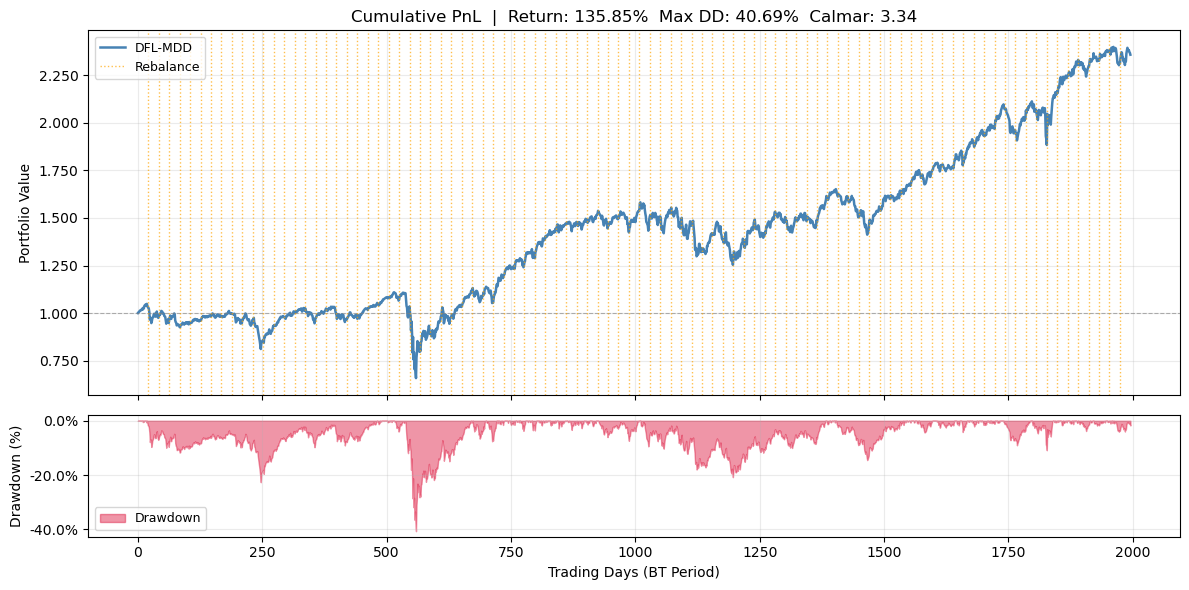


── PnL Summary (DFL-MDD) ──
  Final Value  : 2.3585
  Total Return : 135.8495%
  Max Drawdown : 40.6886%
  Calmar Ratio : 3.3388


In [15]:
import importlib
import dfl_mdd
importlib.reload(dfl_mdd)
from dfl_mdd import (
    PredictionModel,
    build_optimization_layer,
    solve_portfolio,
    compute_cumulative_path,
    compute_realized_path,
    compute_return,
    compute_max_drawdown,
    dfl_loss,
    forward_pass,
    backtest_dfl_mdd,
    plot_pnl,
)

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False 

pred_model = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)
opt_layer  = build_optimization_layer(N, M, gamma)
optimizer  = optim.Adam(pred_model.parameters(), lr=LR)


zs_is = torch.tensor(np.array([s[0] for s in is_samples]), dtype=torch.float32)
rs_is = torch.tensor(np.array([s[1] for s in is_samples]), dtype=torch.float32)

print("\n── IS Training ──")
pred_model.train()

for epoch in range(EPOCHS):
    perm   = torch.randperm(len(is_samples))
    ep_loss = []

    for i in range(0, len(is_samples), BATCH_SIZE):
        idx = perm[i : i + BATCH_SIZE]
        z_b = zs_is[idx]
        r_b = rs_is[idx]

        optimizer.zero_grad()
        result = forward_pass(z_b, r_b, pred_model, opt_layer,
                              n1, C, d, x_min, x_max, lam)
        result["loss"].backward()
        optimizer.step()
        ep_loss.append(result["loss"].item())

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d}/{EPOCHS}  loss = {np.mean(ep_loss):.6f}")


bt_dfl_mdd = backtest_dfl_mdd(
    pred_model    = pred_model,
    opt_layer     = opt_layer,
    rebal_samples = rebal_samples,
    N             = HORIZON,
    d             = d,
    C             = C,
    n1            = n1,
    x_min         = x_min,
    x_max         = x_max,
    stock_names   = stock_names,
)


plot_pnl(bt_dfl_mdd, horizon=HORIZON, label = "DFL-MDD")


── PTO-MDD Training (MSE) ──
  Epoch   1/200  mse = 0.005507
  Epoch   5/200  mse = 0.000446
  Epoch  10/200  mse = 0.000289
  Epoch  15/200  mse = 0.000269
  Epoch  20/200  mse = 0.000264
  Epoch  25/200  mse = 0.000261
  Epoch  30/200  mse = 0.000259
  Epoch  35/200  mse = 0.000257
  Epoch  40/200  mse = 0.000253
  Epoch  45/200  mse = 0.000250
  Epoch  50/200  mse = 0.000247
  Epoch  55/200  mse = 0.000245
  Epoch  60/200  mse = 0.000243
  Epoch  65/200  mse = 0.000242
  Epoch  70/200  mse = 0.000241
  Epoch  75/200  mse = 0.000240
  Epoch  80/200  mse = 0.000239
  Epoch  85/200  mse = 0.000238
  Epoch  90/200  mse = 0.000238
  Epoch  95/200  mse = 0.000237
  Epoch 100/200  mse = 0.000236
  Epoch 105/200  mse = 0.000235
  Epoch 110/200  mse = 0.000234
  Epoch 115/200  mse = 0.000234
  Epoch 120/200  mse = 0.000232
  Epoch 125/200  mse = 0.000232
  Epoch 130/200  mse = 0.000231
  Epoch 135/200  mse = 0.000230
  Epoch 140/200  mse = 0.000229
  Epoch 145/200  mse = 0.000229
  Epoch 15

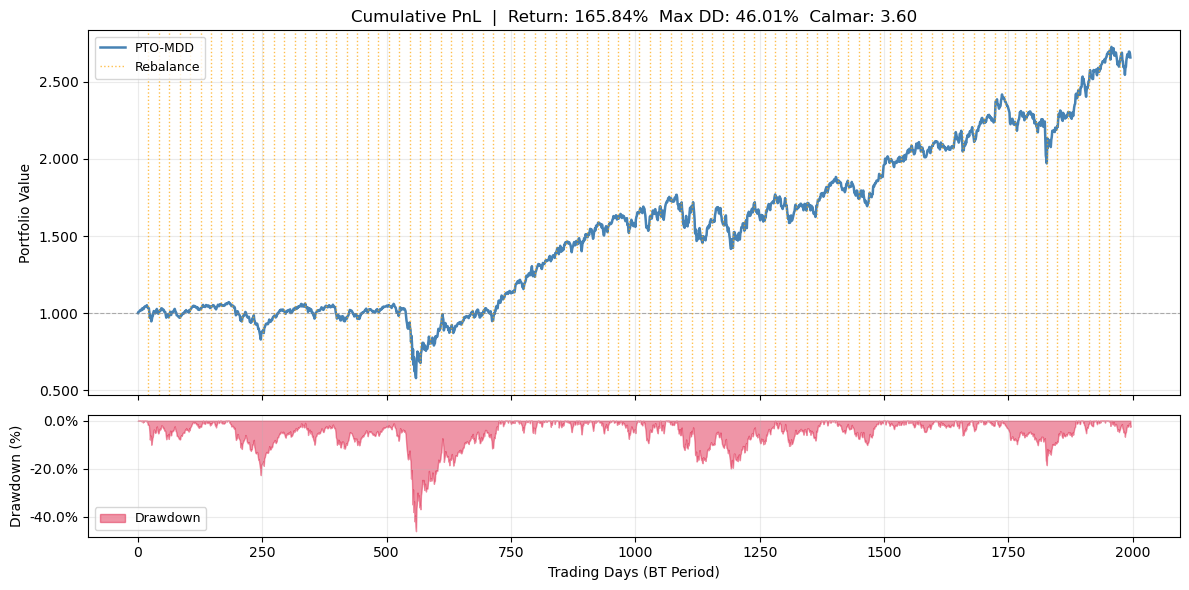


── PnL Summary (PTO-MDD) ──
  Final Value  : 2.6584
  Total Return : 165.8388%
  Max Drawdown : 46.0069%
  Calmar Ratio : 3.6046


In [16]:
import importlib
import pto_mdd
importlib.reload(pto_mdd)
from pto_mdd  import train_pto_mdd,  backtest_pto_mdd

model_pto_mdd = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)

train_pto_mdd(model_pto_mdd, is_samples, EPOCHS, BATCH_SIZE, LR)


bt_pto_mdd = backtest_pto_mdd(
    pred_model   = model_pto_mdd,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    n1           = n1,
    x_min        = x_min,
    x_max        = x_max,
    gamma        = gamma,
    stock_names  = stock_names,
)


plot_pnl(bt_pto_mdd, horizon=HORIZON, label = 'PTO-MDD')



── PTO-MVO Training (MSE) ──
  Epoch   1/200  mse = 0.005594
  Epoch   5/200  mse = 0.000447
  Epoch  10/200  mse = 0.000291
  Epoch  15/200  mse = 0.000270
  Epoch  20/200  mse = 0.000264
  Epoch  25/200  mse = 0.000262
  Epoch  30/200  mse = 0.000261
  Epoch  35/200  mse = 0.000259
  Epoch  40/200  mse = 0.000257
  Epoch  45/200  mse = 0.000254
  Epoch  50/200  mse = 0.000252
  Epoch  55/200  mse = 0.000250
  Epoch  60/200  mse = 0.000247
  Epoch  65/200  mse = 0.000244
  Epoch  70/200  mse = 0.000242
  Epoch  75/200  mse = 0.000240
  Epoch  80/200  mse = 0.000238
  Epoch  85/200  mse = 0.000237
  Epoch  90/200  mse = 0.000235
  Epoch  95/200  mse = 0.000234
  Epoch 100/200  mse = 0.000233
  Epoch 105/200  mse = 0.000232
  Epoch 110/200  mse = 0.000231
  Epoch 115/200  mse = 0.000230
  Epoch 120/200  mse = 0.000229
  Epoch 125/200  mse = 0.000228
  Epoch 130/200  mse = 0.000227
  Epoch 135/200  mse = 0.000226
  Epoch 140/200  mse = 0.000225
  Epoch 145/200  mse = 0.000225
  Epoch 15

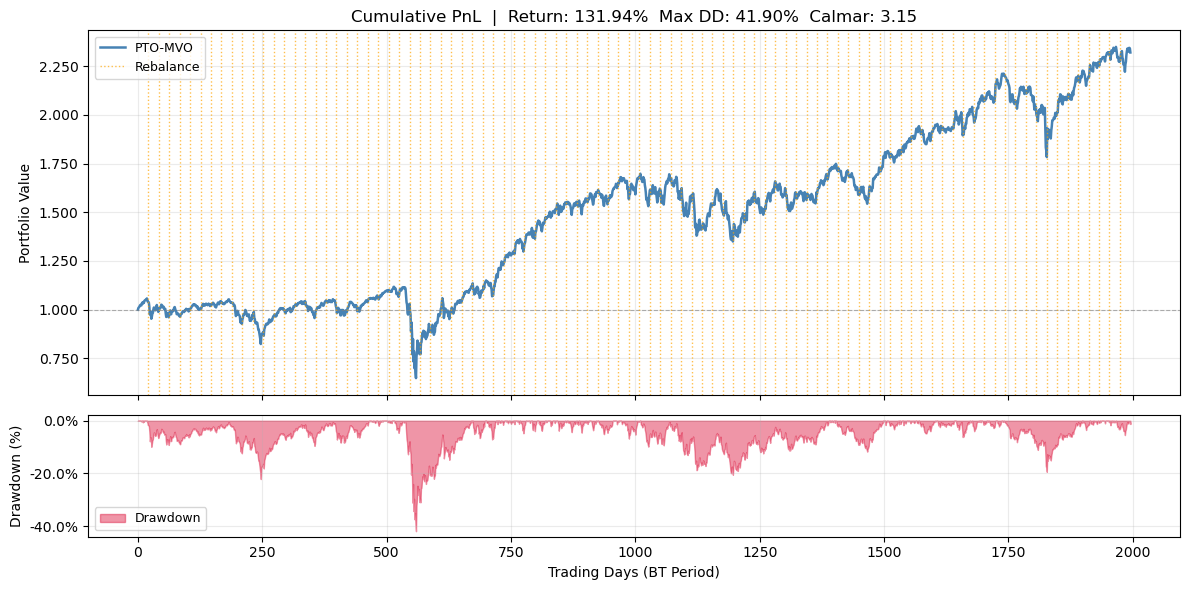


── PnL Summary (PTO-MVO) ──
  Final Value  : 2.3194
  Total Return : 131.9429%
  Max Drawdown : 41.8965%
  Calmar Ratio : 3.1493


In [17]:
import importlib
import pto_mvo
importlib.reload(pto_mvo)
from pto_mvo  import train_pto_mvo,  backtest_pto_mvo 

model_pto_mvo = PredictionModel(INPUT_DIM, HIDDEN_DIM, N, M)

train_pto_mvo(model_pto_mvo, is_samples, EPOCHS, BATCH_SIZE, LR)

bt_pto_mvo = backtest_pto_mvo(
    pred_model   = model_pto_mvo,
    rebal_samples= rebal_samples,
    N            = HORIZON,
    d            = d,
    C            = C,
    lam_mvo      = 1.0,     #risk aversion
    x_min        = x_min,
    x_max        = x_max,
    gamma        = gamma,
    stock_names  = stock_names,
)

plot_pnl(bt_pto_mvo, horizon=HORIZON, label = 'PTO-MVO')